In [2]:
import os
os.environ['ANN3_RUN_MODE'] = 'subset'

# ANN Assignment 3 — PRO in Rank-Calibration Framework

This notebook is Colab-ready and implements your proposed extension:
1. Download full datasets (NQ-Open, TriviaQA, SQuAD, MMLU-Pro).
2. Build MMLU-Pro subset (100 samples).
3. Compute **PRO** uncertainty from saved token logprobs (offline).
4. Evaluate calibration/ranking (ERCE, AUROC) and compare with existing estimators.
5. Add compute-cost comparison for uncertainty estimators.

Use this notebook by uploading your prior reproduction outputs (JSON/JSONL with logprobs).

## Colab Quickstart (single notebook)

You can run the full Assignment 3 pipeline from this notebook alone.

### 1) Runtime mode
- `tiny`: very fast smoke test (2 rows per dataset)
- `subset`: medium run (100 rows per dataset)
- `full`: full datasets (final run)

Set mode before running Cell 3 in Colab:
```python
import os
os.environ['ANN3_RUN_MODE'] = 'tiny'   # or 'subset' / 'full'
```

### 2) Do I need to upload datasets or weights?
- **Datasets:** No upload needed. The notebook downloads datasets automatically.
- **Model weights:** No manual upload needed by default. The notebook tries local model first, then downloads GGUF from Hugging Face.
- If Hugging Face rate limits or private access is needed, set `HF_TOKEN` in Colab secrets/environment.

### 3) When would upload be needed?
- Only if you want to use your own pre-generated JSON/JSONL outputs or a custom local model file.

### 4) Typical Colab run order
1. Cell 2: install dependencies
2. Cell 3: set paths + run mode
3. Cell 5–10: data prep + generation
4. Cell 12 onward: PRO metrics, comparison tables, and plots

In [1]:
# Install dependencies (run once in Colab)
!pip -q install datasets pandas numpy scipy scikit-learn matplotlib seaborn tqdm rouge-score nltk llama-cpp-python huggingface_hub bert-score

In [3]:
import os
import re
import json
import time
import math
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, average_precision_score
from rouge_score import rouge_scorer
from huggingface_hub import hf_hub_download
from llama_cpp import Llama
import nltk

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IS_COLAB = 'google.colab' in str(type(get_ipython())) if 'get_ipython' in globals() else False

def _find_workspace_root(start: Path) -> Optional[Path]:
    checks = [start, *start.parents]
    for c in checks:
        if (c / 'notebooks' / 'pro_rank_calibration.ipynb').exists() and (c / 'data').exists():
            return c

    scan_roots = [Path.cwd(), Path.home() / 'Desktop']
    for root in scan_roots:
        if not root.exists():
            continue
        try:
            for nb in root.rglob('notebooks/pro_rank_calibration.ipynb'):
                candidate = nb.parent.parent
                if (candidate / 'data').exists():
                    return candidate
        except Exception:
            continue
    return None

base_override = os.getenv('ANN3_BASE_DIR', '').strip()
if base_override:
    BASE_DIR = Path(base_override).expanduser().resolve()
elif IS_COLAB:
    BASE_DIR = Path('/content/ann3_pro_rankcal')
else:
    root = _find_workspace_root(Path.cwd())
    BASE_DIR = root if root is not None else Path.cwd().resolve()

RAW_DIR = BASE_DIR / 'data' / 'raw'
PROC_DIR = BASE_DIR / 'data' / 'processed'
INPUT_RESULTS_DIR = BASE_DIR / 'input_results'
OUTPUT_DIR = BASE_DIR / 'output'
GENERATED_DIR = OUTPUT_DIR / 'generated_results'
PLOTS_DIR = OUTPUT_DIR / 'plots'

# Runtime presets: tiny (fast debug), subset (medium), full (final run)
RUN_MODE = os.getenv('ANN3_RUN_MODE', 'tiny').strip().lower()  # tiny | subset | full
RUN_DATASETS = ['nq_open', 'triviaqa', 'squad', 'mmlu_pro']

TINY_ROWS = 2
SUBSET_ROWS = 100
FORCE_REGENERATE = False

if RUN_MODE not in {'tiny', 'subset', 'full'}:
    raise ValueError("RUN_MODE must be one of: 'tiny', 'subset', 'full'")

for d in [RAW_DIR, PROC_DIR, INPUT_RESULTS_DIR, OUTPUT_DIR, GENERATED_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('BASE_DIR:', BASE_DIR)
print('IS_COLAB:', IS_COLAB)
print('RUN_MODE:', RUN_MODE)
print('RUN_DATASETS:', RUN_DATASETS)

/home/abdullah/Desktop/TUFF/pdc ann project/uncertainty-aware-distributed-inference/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BASE_DIR: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference
IS_COLAB: False
RUN_MODE: subset
RUN_DATASETS: ['nq_open', 'triviaqa', 'squad', 'mmlu_pro']


## 1) Download full datasets + create unified JSONL
This downloads full splits and creates canonical records:
`{id, original_prompt, ground_truth}`.

In [4]:
def _json_default(obj: Any):
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f'Object of type {type(obj).__name__} is not JSON serializable')

def write_jsonl(path: Path, rows: List[Dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False, default=_json_default) + '\n')

def _count_jsonl(path: Path) -> int:
    if not path.exists():
        return 0
    with path.open('r', encoding='utf-8') as f:
        return sum(1 for line in f if line.strip())

def download_full_datasets() -> Dict[str, int]:
    counts = {}

    out_nq = PROC_DIR / 'nq_open_full.jsonl'
    out_trivia = PROC_DIR / 'triviaqa_full.jsonl'
    out_squad = PROC_DIR / 'squad_full.jsonl'
    out_mmlu = PROC_DIR / 'mmlu_pro_full.jsonl'

    if all(p.exists() for p in [out_nq, out_trivia, out_squad, out_mmlu]):
        counts['nq_open_full'] = _count_jsonl(out_nq)
        counts['triviaqa_full'] = _count_jsonl(out_trivia)
        counts['squad_full'] = _count_jsonl(out_squad)
        counts['mmlu_pro_full'] = _count_jsonl(out_mmlu)
        print('Using existing full dataset JSONL files.')
        return counts

    nq = load_dataset('nq_open', split='validation')
    nq.save_to_disk(str(RAW_DIR / 'nq_open_validation'))
    nq_rows = []
    for i, item in enumerate(nq, start=1):
        answers = item.get('answer', [])
        if not isinstance(answers, list):
            answers = [str(answers)]
        nq_rows.append({
            'id': i,
            'dataset': 'nq_open',
            'original_prompt': item.get('question', ''),
            'ground_truth': [str(a) for a in answers],
        })
    write_jsonl(out_nq, nq_rows)
    counts['nq_open_full'] = len(nq_rows)

    trivia = load_dataset('trivia_qa', 'rc.nocontext', split='validation')
    trivia.save_to_disk(str(RAW_DIR / 'triviaqa_validation_rc_nocontext'))
    trivia_rows = []
    for i, item in enumerate(trivia, start=1):
        answer_obj = item.get('answer', {})
        aliases = answer_obj.get('aliases', []) if isinstance(answer_obj, dict) else []
        if not aliases:
            aliases = [str(answer_obj)]
        trivia_rows.append({
            'id': i,
            'dataset': 'triviaqa',
            'original_prompt': item.get('question', ''),
            'ground_truth': [str(a) for a in aliases],
        })
    write_jsonl(out_trivia, trivia_rows)
    counts['triviaqa_full'] = len(trivia_rows)

    squad = load_dataset('squad', split='validation')
    squad.save_to_disk(str(RAW_DIR / 'squad_validation'))
    squad_rows = []
    for i, item in enumerate(squad, start=1):
        answers = item.get('answers', {})
        texts = answers.get('text', []) if isinstance(answers, dict) else []
        squad_rows.append({
            'id': i,
            'dataset': 'squad',
            'original_prompt': item.get('question', ''),
            'ground_truth': [str(a) for a in texts],
        })
    write_jsonl(out_squad, squad_rows)
    counts['squad_full'] = len(squad_rows)

    mmlu = load_dataset('TIGER-Lab/MMLU-Pro', split='test')
    mmlu.save_to_disk(str(RAW_DIR / 'mmlu_pro_test'))
    mmlu_rows = []
    for i, item in enumerate(mmlu, start=1):
        q = item.get('question', '')
        options = item.get('options', [])
        prompt = f"{q}\nChoices: {options}"
        mmlu_rows.append({
            'id': i,
            'dataset': 'mmlu_pro',
            'subject': str(item.get('category', 'unknown')),
            'original_prompt': prompt,
            'ground_truth': [str(item.get('answer', ''))],
        })
    write_jsonl(out_mmlu, mmlu_rows)
    counts['mmlu_pro_full'] = len(mmlu_rows)

    return counts

counts = download_full_datasets()
counts

Using existing full dataset JSONL files.


{'nq_open_full': 3610,
 'triviaqa_full': 17944,
 'squad_full': 10570,
 'mmlu_pro_full': 12032}

In [5]:
# Create runtime-selected files before running the pipeline
def read_jsonl(path: Path) -> List[Dict[str, Any]]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

def proportional_subset(rows: List[Dict[str, Any]], target_size: int, stratify_key: Optional[str] = None) -> List[Dict[str, Any]]:
    if target_size >= len(rows):
        return rows.copy()

    rng = random.Random(SEED)
    if not stratify_key:
        return rng.sample(rows, target_size)

    grouped: Dict[str, List[Dict[str, Any]]] = {}
    for row in rows:
        label = str(row.get(stratify_key, 'unknown'))
        grouped.setdefault(label, []).append(row)

    if len(grouped) <= 1:
        return rng.sample(rows, target_size)

    total = len(rows)
    alloc: Dict[str, int] = {}
    remainders: List[Tuple[float, str]] = []
    used = 0

    for label, grp in grouped.items():
        frac = len(grp) / total
        raw = frac * target_size
        take = min(len(grp), int(math.floor(raw)))
        alloc[label] = take
        used += take
        remainders.append((raw - math.floor(raw), label))

    remaining = target_size - used
    for _, label in sorted(remainders, reverse=True):
        if remaining <= 0:
            break
        if alloc[label] < len(grouped[label]):
            alloc[label] += 1
            remaining -= 1

    subset: List[Dict[str, Any]] = []
    for label, grp in grouped.items():
        take = alloc[label]
        if take > 0:
            subset.extend(rng.sample(grp, take))

    if len(subset) < target_size:
        already = {id(x) for x in subset}
        pool = [r for r in rows if id(r) not in already]
        subset.extend(rng.sample(pool, target_size - len(subset)))

    rng.shuffle(subset)
    return subset[:target_size]

dataset_files = {
    'nq_open': PROC_DIR / 'nq_open_full.jsonl',
    'triviaqa': PROC_DIR / 'triviaqa_full.jsonl',
    'squad': PROC_DIR / 'squad_full.jsonl',
    'mmlu_pro': PROC_DIR / 'mmlu_pro_full.jsonl',
}

if RUN_MODE == 'tiny':
    target_rows = TINY_ROWS
elif RUN_MODE == 'subset':
    target_rows = SUBSET_ROWS
else:
    target_rows = None  # full

runtime_manifest = {}
for name, path in dataset_files.items():
    if name not in RUN_DATASETS:
        continue

    rows = read_jsonl(path)
    stratify_key = 'subject' if name == 'mmlu_pro' else None

    if RUN_MODE == 'full':
        selected = rows
    else:
        selected = proportional_subset(rows, min(target_rows, len(rows)), stratify_key=stratify_key)

    for i, row in enumerate(selected, start=1):
        row['id'] = i

    out = PROC_DIR / f'{name}_runtime.jsonl'
    write_jsonl(out, selected)
    runtime_manifest[name] = {'path': str(out), 'size': len(selected), 'stratified_on': stratify_key}

runtime_manifest

{'nq_open': {'path': '/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/data/processed/nq_open_runtime.jsonl',
  'size': 100,
  'stratified_on': None},
 'triviaqa': {'path': '/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/data/processed/triviaqa_runtime.jsonl',
  'size': 100,
  'stratified_on': None},
 'squad': {'path': '/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/data/processed/squad_runtime.jsonl',
  'size': 100,
  'stratified_on': None},
 'mmlu_pro': {'path': '/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/data/processed/mmlu_pro_runtime.jsonl',
  'size': 100,
  'stratified_on': 'subject'}}

## 2) Download model weights and run generation pipeline
This section is fully standalone: it downloads GGUF model weights, loads `llama-cpp`, runs inference on subset files, and writes JSONL outputs used by later calibration cells.

In [6]:
MODEL_REPO_PRIMARY = 'bartowski/Llama-3.2-3B-Instruct-GGUF'
MODEL_FILE_PRIMARY = 'Llama-3.2-3B-Instruct-Q4_K_M.gguf'

MODEL_REPO_FALLBACK = 'TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF'
MODEL_FILE_FALLBACK = 'tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf'

MODEL_DIR = BASE_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def resolve_local_model() -> Optional[Path]:
    local_candidates = [
        BASE_DIR / 'models' / 'llama-3.2-3b-instruct-q4_k_m.gguf',
        BASE_DIR / 'models' / 'Llama-3.2-3B-Instruct-Q4_K_M.gguf',
        Path.cwd() / 'models' / 'llama-3.2-3b-instruct-q4_k_m.gguf',
        Path.cwd() / 'models' / 'Llama-3.2-3B-Instruct-Q4_K_M.gguf',
    ]
    for p in local_candidates:
        if p.exists():
            return p
    ggufs = list((Path.cwd() / 'models').glob('*.gguf')) if (Path.cwd() / 'models').exists() else []
    return ggufs[0] if ggufs else None

def download_model_gguf() -> Path:
    existing = resolve_local_model()
    if existing is not None:
        print('Using existing local model:', existing)
        return existing

    token = os.getenv('HF_TOKEN', None)
    try:
        path = hf_hub_download(
            repo_id=MODEL_REPO_PRIMARY,
            filename=MODEL_FILE_PRIMARY,
            token=token,
            local_dir=str(MODEL_DIR),
            local_dir_use_symlinks=False,
        )
        print('Downloaded primary model:', path)
        return Path(path)
    except Exception as e:
        print('Primary model download failed:', e)
        print('Falling back to TinyLlama GGUF...')
        path = hf_hub_download(
            repo_id=MODEL_REPO_FALLBACK,
            filename=MODEL_FILE_FALLBACK,
            token=token,
            local_dir=str(MODEL_DIR),
            local_dir_use_symlinks=False,
        )
        print('Downloaded fallback model:', path)
        return Path(path)

MODEL_PATH = download_model_gguf()
MODEL_PATH

Using existing local model: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/models/llama-3.2-3b-instruct-q4_k_m.gguf


PosixPath('/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/models/llama-3.2-3b-instruct-q4_k_m.gguf')

In [7]:
N_THREADS = max(2, (os.cpu_count() or 4) // 2)
N_CTX = 2048
MAX_TOKENS = 32 if RUN_MODE == 'tiny' else 128
PROBE_TOKENS = 8 if RUN_MODE == 'tiny' else 20
TEMPERATURE = 0.6
TOP_P = 0.9
TOP_LOGPROBS = 10
ENABLE_BERTSCORE = False  # set True for full evaluation in Colab

llm = Llama(
    model_path=str(MODEL_PATH),
    n_threads=N_THREADS,
    n_ctx=N_CTX,
    logits_all=True,
    verbose=False,
 )

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def _safe_text(x: Any) -> str:
    return str(x).strip() if x is not None else ''

def generate_with_logprobs(prompt: str, max_tokens: int) -> Dict[str, Any]:
    started = time.perf_counter()
    completion = llm(
        prompt,
        max_tokens=max_tokens,
        temperature=TEMPERATURE,
        top_p=TOP_P,
        logprobs=TOP_LOGPROBS,
    )
    elapsed_ms = int((time.perf_counter() - started) * 1000)
    ch = completion['choices'][0]
    lp = ch.get('logprobs', {}) or {}
    token_logprobs = lp.get('token_logprobs', []) or []
    top_logprobs = lp.get('top_logprobs', []) or []

    pro_logprobs = []
    if top_logprobs and isinstance(top_logprobs[0], dict):
        pro_logprobs = [float(v) for _, v in sorted(top_logprobs[0].items(), key=lambda kv: kv[1], reverse=True)[:TOP_LOGPROBS]]
    else:
        pro_logprobs = [float(x) for x in token_logprobs[:TOP_LOGPROBS] if x is not None]

    return {
        'text': _safe_text(ch.get('text', '')),
        'token_logprobs': [float(x) for x in token_logprobs if x is not None],
        'pro_logprobs': pro_logprobs,
        'top_logprobs': top_logprobs,
        'latency_ms': elapsed_ms,
    }

def best_rouge_scores(prediction: str, refs: List[str]) -> Dict[str, float]:
    if not prediction or not refs:
        return {'rouge1': float('nan'), 'rougeL': float('nan')}
    r1, rl = [], []
    for r in refs:
        ref = _safe_text(r)
        if not ref:
            continue
        s = scorer.score(ref, prediction)
        r1.append(s['rouge1'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    if not r1:
        return {'rouge1': float('nan'), 'rougeL': float('nan')}
    return {'rouge1': float(max(r1)), 'rougeL': float(max(rl))}

def simple_bleu(prediction: str, refs: List[str]) -> float:
    pred_tokens = prediction.split()
    if not pred_tokens or not refs:
        return float('nan')
    ref_tokens = [set(_safe_text(r).split()) for r in refs if _safe_text(r)]
    if not ref_tokens:
        return float('nan')
    overlap = max(len(set(pred_tokens) & rt) / max(len(pred_tokens), 1) for rt in ref_tokens)
    return float(overlap)

def nll_from_token_logprobs(token_logprobs: List[float]) -> float:
    if not token_logprobs:
        return float('nan')
    return float(-np.mean(np.array(token_logprobs, dtype=float)))

def uecc_proxy(token_logprobs: List[float]) -> float:
    if not token_logprobs:
        return float('nan')
    arr = np.array(token_logprobs, dtype=float)
    return float(np.std(arr))

def udeg_proxy(token_logprobs: List[float]) -> float:
    if not token_logprobs:
        return float('nan')
    arr = np.array(token_logprobs, dtype=float)
    probs = np.exp(arr - np.max(arr))
    probs = probs / (np.sum(probs) + 1e-12)
    return float(-np.sum(probs * np.log(probs + 1e-12)))

def bertscore_optional(prediction: str, refs: List[str]) -> float:
    if not ENABLE_BERTSCORE or not prediction or not refs:
        return float('nan')
    try:
        from bert_score import score as bert_score
        _, _, f1 = bert_score([prediction] * len(refs), refs, lang='en', verbose=False)
        return float(f1.mean().item())
    except Exception:
        return float('nan')

In [8]:
subset_files = {name: PROC_DIR / f'{name}_runtime.jsonl' for name in RUN_DATASETS}

def run_pipeline_on_subset(dataset_name: str, path: Path) -> Path:
    rows = read_jsonl(path)
    output_path = GENERATED_DIR / f'{dataset_name}_generated.jsonl'

    if output_path.exists() and not FORCE_REGENERATE:
        existing_n = _count_jsonl(output_path)
        if existing_n == len(rows) and existing_n > 0:
            print(f'Using existing generated file for {dataset_name}: {output_path.name}')
            return output_path
        print(f'Regenerating {dataset_name}: existing rows={existing_n}, expected rows={len(rows)}')

    generated_rows = []
    for row in tqdm(rows, desc=f'Generating {dataset_name}'):
        prompt = _safe_text(row.get('original_prompt', ''))
        refs = [str(x) for x in row.get('ground_truth', [])]

        probe = generate_with_logprobs(prompt, max_tokens=PROBE_TOKENS)
        full = generate_with_logprobs(prompt, max_tokens=MAX_TOKENS)
        rouge_vals = best_rouge_scores(full['text'], refs)

        record = {
            'id': row.get('id'),
            'dataset': dataset_name,
            'original_prompt': prompt,
            'ground_truth': refs,
            'prediction': full['text'],
            'logprobs': full['token_logprobs'],
            'pro_logprobs': probe['pro_logprobs'],
            'top_logprobs': probe['top_logprobs'],
            'correctness': {
                'rouge1': float(rouge_vals['rouge1']) if not np.isnan(rouge_vals['rouge1']) else float('nan'),
                'rougeL': float(rouge_vals['rougeL']) if not np.isnan(rouge_vals['rougeL']) else float('nan'),
                'bleu': float(simple_bleu(full['text'], refs)),
                'meteor': float('nan'),
                'bert': float(bertscore_optional(full['text'], refs)),
            },
            'NLL': float(nll_from_token_logprobs(full['token_logprobs'])),
            'UEcc': float(uecc_proxy(full['token_logprobs'])),
            'UDeg': float(udeg_proxy(full['token_logprobs'])),
            'latency_ms': int(probe['latency_ms'] + full['latency_ms']),
            'probe_latency_ms': int(probe['latency_ms']),
            'generation_latency_ms': int(full['latency_ms']),
        }
        generated_rows.append(record)

    write_jsonl(output_path, generated_rows)
    return output_path

generated_paths = {}
for name, p in subset_files.items():
    if not p.exists():
        print(f'Skipping {name}: runtime file not found ({p.name})')
        continue
    generated_paths[name] = run_pipeline_on_subset(name, p)

generated_paths

Generating mmlu_pro: 100%|██████████| 100/100 [2:43:49<00:00, 98.29s/it]  


{'nq_open': PosixPath('/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/generated_results/nq_open_generated.jsonl'),
 'triviaqa': PosixPath('/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/generated_results/triviaqa_generated.jsonl'),
 'squad': PosixPath('/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/generated_results/squad_generated.jsonl'),
 'mmlu_pro': PosixPath('/media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/generated_results/mmlu_pro_generated.jsonl')}

## 3) PRO uncertainty score (computed from generated logprobs)
These functions support both this notebook’s generated outputs and external JSON/JSONL schemas if you later add them.

In [9]:
def extract_token_logprobs(record: Dict[str, Any]) -> List[float]:
    candidates = [
        record.get('pro_logprobs'),
        record.get('logprobs'),
        record.get('token_logprobs'),
        record.get('completion_logprobs'),
    ]

    if isinstance(record.get('generation'), dict):
        gen = record['generation']
        candidates.extend([
            gen.get('pro_logprobs'),
            gen.get('logprobs'),
            gen.get('token_logprobs'),
            gen.get('completion_logprobs'),
        ])

    for c in candidates:
        if isinstance(c, list) and c and isinstance(c[0], (int, float)):
            return [float(x) for x in c if x is not None]

    try:
        lp = record['choices'][0]['logprobs']['token_logprobs']
        if isinstance(lp, list):
            return [float(x) for x in lp if x is not None]
    except Exception:
        pass

    return []

def extract_topk_logprobs_first_token(record: Dict[str, Any], top_k: int = 10) -> List[float]:
    top = record.get('top_logprobs')
    if isinstance(top, list) and len(top) > 0 and isinstance(top[0], dict):
        vals = [float(v) for _, v in sorted(top[0].items(), key=lambda kv: kv[1], reverse=True)[:top_k]]
        return vals

    if isinstance(record.get('generation'), dict):
        gtop = record['generation'].get('top_logprobs')
        if isinstance(gtop, list) and len(gtop) > 0 and isinstance(gtop[0], dict):
            vals = [float(v) for _, v in sorted(gtop[0].items(), key=lambda kv: kv[1], reverse=True)[:top_k]]
            return vals

    return []

def compute_pro_score(token_logprobs: List[float], top_k: int = 10, min_prob: float = 1e-8) -> float:
    if not token_logprobs:
        return float('nan')

    vals = np.array(token_logprobs[:top_k], dtype=float)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return float('nan')

    probs = np.exp(vals)
    probs = probs[probs >= min_prob]
    if probs.size < 2:
        return float('nan')
    probs = probs / (probs.sum() + 1e-12)

    k = len(probs)
    entropy = -np.sum(probs * np.log(probs + 1e-12))
    return float(entropy / np.log(k))

def classify_uncertainty(score: float, tau: float = 0.5) -> str:
    if np.isnan(score):
        return 'unknown'
    return 'high' if score > tau else 'low'

## 4) Load generated outputs and add PRO column
If `INPUT_RESULTS_DIR` is empty, this cell automatically uses `OUTPUT_DIR/generated_results` from this notebook run.

In [10]:
def load_json_or_jsonl(path: Path) -> List[Dict[str, Any]]:
    if path.suffix.lower() == '.jsonl':
        with path.open('r', encoding='utf-8') as f:
            return [json.loads(line) for line in f if line.strip()]
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)
    if isinstance(data, list):
        return data
    if isinstance(data, dict):
        for key in ['records', 'results', 'samples', 'data']:
            if key in data and isinstance(data[key], list):
                return data[key]
    return []

def get_correctness_value(record: Dict[str, Any], preferred: str = 'rouge1') -> float:
    corr = record.get('correctness')
    if isinstance(corr, dict):
        if preferred in corr and corr[preferred] is not None:
            return float(corr[preferred])
        for k in ['bert', 'bertscore', 'rougeL', 'rouge1']:
            if k in corr and corr[k] is not None:
                return float(corr[k])
    for k in ['correctness', 'quality', 'score', 'rouge1', 'bert']:
        if isinstance(record.get(k), (int, float)):
            return float(record[k])
    return float('nan')

def add_pro_to_records(records: List[Dict[str, Any]], top_k: int = 10) -> pd.DataFrame:
    rows = []
    for r in records:
        t0 = time.perf_counter()
        topk_lps = extract_topk_logprobs_first_token(r, top_k=top_k)
        token_lps = topk_lps if topk_lps else extract_token_logprobs(r)
        pro = compute_pro_score(token_lps, top_k=top_k)
        pro_cost_ms = (time.perf_counter() - t0) * 1000.0
        rows.append({
            'id': r.get('id'),
            'pro_score': pro,
            'pro_cost_ms': pro_cost_ms,
            'correctness': get_correctness_value(r),
            'raw_record': r,
        })
    return pd.DataFrame(rows)

result_files = sorted([p for p in INPUT_RESULTS_DIR.glob('*') if p.suffix.lower() in {'.json', '.jsonl'}])
if not result_files:
    result_files = sorted([p for p in GENERATED_DIR.glob('*') if p.suffix.lower() in {'.json', '.jsonl'}])

print('Using result files:', [p.name for p in result_files])

dataset_frames = {}
for p in result_files:
    recs = load_json_or_jsonl(p)
    if not recs:
        continue
    df = add_pro_to_records(recs, top_k=10)
    dataset_frames[p.stem] = df
    out_csv = OUTPUT_DIR / f'{p.stem}_with_pro.csv'
    df.drop(columns=['raw_record']).to_csv(out_csv, index=False)
    print(f'{p.name}: {len(df)} rows -> {out_csv.name}')

Using result files: ['mmlu_pro_generated.jsonl', 'nq_open_generated.jsonl', 'squad_generated.jsonl', 'triviaqa_generated.jsonl']
mmlu_pro_generated.jsonl: 100 rows -> mmlu_pro_generated_with_pro.csv
nq_open_generated.jsonl: 100 rows -> nq_open_generated_with_pro.csv
squad_generated.jsonl: 100 rows -> squad_generated_with_pro.csv
triviaqa_generated.jsonl: 100 rows -> triviaqa_generated_with_pro.csv


## 5) Rank-calibration metrics (ERCE + AUROC)
Assumes higher uncertainty should correlate with lower correctness.

In [11]:
def compute_rce(scores: np.ndarray, correctness: np.ndarray) -> float:
    mask = ~np.isnan(scores) & ~np.isnan(correctness)
    s = scores[mask]
    c = correctness[mask]
    if len(s) == 0:
        return float('nan')
    order = np.argsort(s)
    c_sorted = c[order]
    n = len(c_sorted)
    u_cdf = np.linspace(1.0 / n, 1.0, n)
    c_cdf = np.cumsum(c_sorted) / (np.sum(c_sorted) + 1e-12)
    return float(np.mean(np.abs(c_cdf - u_cdf)))

def compute_erce(scores: np.ndarray, correctness: np.ndarray, n_bins: int = 10) -> float:
    mask = ~np.isnan(scores) & ~np.isnan(correctness)
    scores = scores[mask]
    correctness = correctness[mask]
    if len(scores) == 0:
        return float('nan')

    ranks = scores.argsort().argsort().astype(float)
    u = ranks / max(len(scores) - 1, 1)

    bins = np.linspace(0, 1, n_bins + 1)
    erce_vals = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        sel = (u >= lo) & (u < hi if i < n_bins - 1 else u <= hi)
        if not np.any(sel):
            continue
        mean_u = np.mean(u[sel])
        mean_c = np.mean(correctness[sel])
        erce_vals.append(abs(mean_c - (1 - mean_u)))

    if not erce_vals:
        return float('nan')
    return float(np.mean(erce_vals))

def _binary_error_labels(correctness: np.ndarray) -> np.ndarray:
    threshold = np.nanmedian(correctness)
    return (correctness < threshold).astype(int)

def compute_auroc(scores: np.ndarray, correctness: np.ndarray) -> float:
    mask = ~np.isnan(scores) & ~np.isnan(correctness)
    s = scores[mask]
    c = correctness[mask]
    if len(s) < 2:
        return float('nan')
    labels = _binary_error_labels(c)
    if labels.min() == labels.max():
        return float('nan')
    return float(roc_auc_score(labels, s))

def compute_auprc(scores: np.ndarray, correctness: np.ndarray) -> float:
    mask = ~np.isnan(scores) & ~np.isnan(correctness)
    s = scores[mask]
    c = correctness[mask]
    if len(s) < 2:
        return float('nan')
    labels = _binary_error_labels(c)
    if labels.min() == labels.max():
        return float('nan')
    return float(average_precision_score(labels, s))

def compute_auarc(scores: np.ndarray, correctness: np.ndarray) -> float:
    mask = ~np.isnan(scores) & ~np.isnan(correctness)
    s = scores[mask]
    c = correctness[mask]
    if len(s) < 2:
        return float('nan')

    order = np.argsort(s)  # keep most certain first
    c_sorted = c[order]
    coverages = np.arange(1, len(c_sorted) + 1) / len(c_sorted)
    acc_curve = np.cumsum(c_sorted) / np.arange(1, len(c_sorted) + 1)
    return float(np.trapz(acc_curve, coverages))

summary_rows = []
for name, df in dataset_frames.items():
    s = df['pro_score'].to_numpy(dtype=float)
    c = df['correctness'].to_numpy(dtype=float)
    summary_rows.append({
        'dataset': name,
        'n': int((~np.isnan(s) & ~np.isnan(c)).sum()),
        'RCE_PRO': compute_rce(s, c),
        'ERCE_PRO': compute_erce(s, c, n_bins=10),
        'AUROC_PRO': compute_auroc(s, c),
        'AUARC_PRO': compute_auarc(s, c),
        'AUPRC_PRO': compute_auprc(s, c),
        'PRO_cost_ms_mean': float(np.nanmean(df['pro_cost_ms'].to_numpy(dtype=float))),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('dataset').reset_index(drop=True)
summary_df

,dataset,n,RCE_PRO,ERCE_PRO,AUROC_PRO,AUARC_PRO,AUPRC_PRO,PRO_cost_ms_mean
0,mmlu_pro_generated,100,0.087293,0.488257,NaN,0.011254,NaN,0.100495
1,nq_open_generated,100,0.026439,0.467404,0.573718,0.033465,0.583334,0.069751
2,squad_generated,100,0.054229,0.471587,0.497600,0.023964,0.570896,0.028077
3,triviaqa_generated,100,0.065310,0.445841,0.626800,0.060609,0.638252,0.055099


## 6) Add/compare baseline uncertainty estimators from generated outputs
This compares PRO with any baseline columns present in records (e.g., UDeg, UEcc, UEigV, USE, NLL).

In [12]:
BASELINE_KEYS = ['UDeg', 'UEcc', 'UEigV', 'USE', 'NLL']

def extract_method_column(df_raw: pd.DataFrame, key: str) -> np.ndarray:
    if key in df_raw.columns:
        return df_raw[key].astype(float).to_numpy()
    vals = []
    for r in df_raw['raw_record']:
        v = r.get(key, np.nan) if isinstance(r, dict) else np.nan
        vals.append(float(v) if isinstance(v, (int, float)) else np.nan)
    return np.array(vals, dtype=float)

compare_rows = []
for name, df in dataset_frames.items():
    corr = df['correctness'].to_numpy(dtype=float)

    pro_scores = df['pro_score'].to_numpy(dtype=float)
    compare_rows.append({
        'dataset': name, 'method': 'PRO',
        'RCE': compute_rce(pro_scores, corr),
        'ERCE': compute_erce(pro_scores, corr),
        'AUROC': compute_auroc(pro_scores, corr),
        'AUARC': compute_auarc(pro_scores, corr),
        'AUPRC': compute_auprc(pro_scores, corr),
        'mean_compute_ms': float(np.nanmean(df['pro_cost_ms'].to_numpy(dtype=float))),
    })

    for m in BASELINE_KEYS:
        ms = extract_method_column(df, m)
        if np.isnan(ms).all():
            continue
        compare_rows.append({
            'dataset': name, 'method': m,
            'RCE': compute_rce(ms, corr),
            'ERCE': compute_erce(ms, corr),
            'AUROC': compute_auroc(ms, corr),
            'AUARC': compute_auarc(ms, corr),
            'AUPRC': compute_auprc(ms, corr),
            'mean_compute_ms': np.nan,
        })

compare_df = pd.DataFrame(compare_rows)
compare_df.sort_values(['dataset', 'method']).reset_index(drop=True)

,dataset,method,RCE,ERCE,AUROC,AUARC,AUPRC,mean_compute_ms
0,mmlu_pro_generated,NLL,0.118214,0.488257,NaN,0.018237,NaN,NaN
1,mmlu_pro_generated,PRO,0.087293,0.488257,NaN,0.011254,NaN,0.100495
2,mmlu_pro_generated,UDeg,0.295902,0.488257,NaN,0.035633,NaN,NaN
3,mmlu_pro_generated,UEcc,0.135882,0.488257,NaN,0.020886,NaN,NaN
4,nq_open_generated,NLL,0.048653,0.467404,0.660256,0.036640,0.692881,NaN
5,nq_open_generated,PRO,0.026439,0.467404,0.573718,0.033465,0.583334,0.069751
6,nq_open_generated,UDeg,0.056701,0.467544,0.318109,0.025917,0.386411,NaN
7,nq_open_generated,UEcc,0.040736,0.467404,0.641026,0.036113,0.668577,NaN
8,squad_generated,NLL,0.035202,0.471587,0.486800,0.025077,0.528552,NaN
9,squad_generated,PRO,0.054229,0.471587,0.497600,0.023964,0.570896,0.028077


In [13]:
# Save final tables and metrics artifacts
summary_df.to_csv(OUTPUT_DIR / 'pro_summary_metrics.csv', index=False)
summary_df.to_json(OUTPUT_DIR / 'pro_summary_metrics.json', orient='records', indent=2)

if 'compare_df' in globals() and len(compare_df) > 0:
    compare_df.to_csv(OUTPUT_DIR / 'uncertainty_method_comparison.csv', index=False)
    compare_df.to_json(OUTPUT_DIR / 'uncertainty_method_comparison.json', orient='records', indent=2)

print('Saved:', OUTPUT_DIR / 'pro_summary_metrics.csv')
print('Saved:', OUTPUT_DIR / 'pro_summary_metrics.json')
print('Saved:', OUTPUT_DIR / 'uncertainty_method_comparison.csv')
print('Saved:', OUTPUT_DIR / 'uncertainty_method_comparison.json')

print('\nFinal PRO summary metrics:')
print(summary_df.to_string(index=False))

if 'compare_df' in globals() and len(compare_df) > 0:
    print('\nFinal method comparison metrics:')
    print(compare_df.sort_values(['dataset', 'method']).to_string(index=False))

Saved: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/pro_summary_metrics.csv
Saved: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/pro_summary_metrics.json
Saved: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/uncertainty_method_comparison.csv
Saved: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/uncertainty_method_comparison.json

Final PRO summary metrics:
           dataset   n  RCE_PRO  ERCE_PRO  AUROC_PRO  AUARC_PRO  AUPRC_PRO  PRO_cost_ms_mean
mmlu_pro_generated 100 0.087293  0.488257        NaN   0.011254        NaN          0.100495
 nq_open_generated 100 0.026439  0.467404   0.573718   0.033465   0.583334          0.069751
   squad_generated 100 0.054229  0.471587   0.497600   0.023964   0.570896          0.028077
triviaqa_generated 100 0.065310  0.445841   0.626800   0.060609   0.638252          0.055099

Final method comparison 

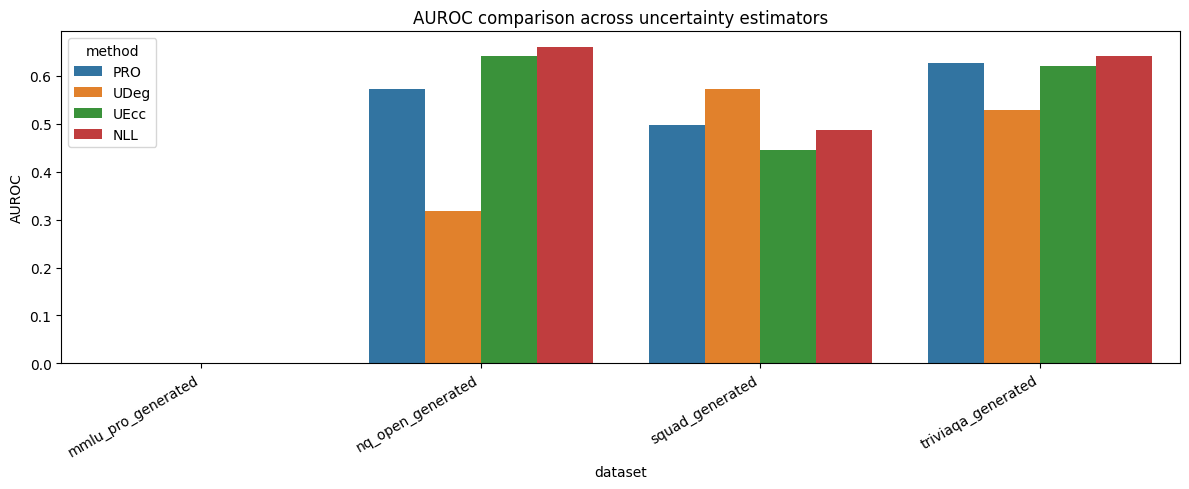

Saved plot: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/plots/auroc_comparison.png


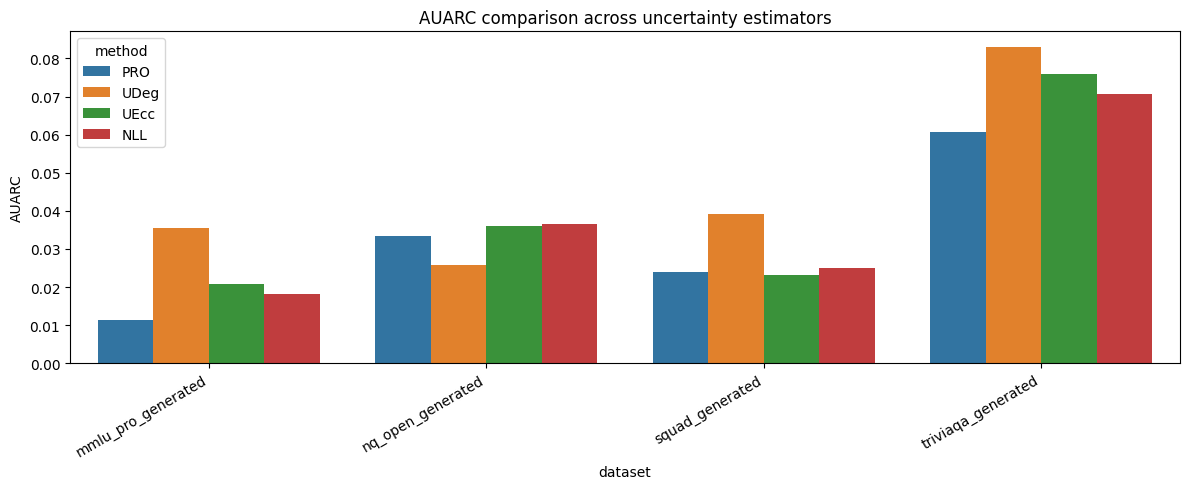

Saved plot: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/plots/auarc_comparison.png


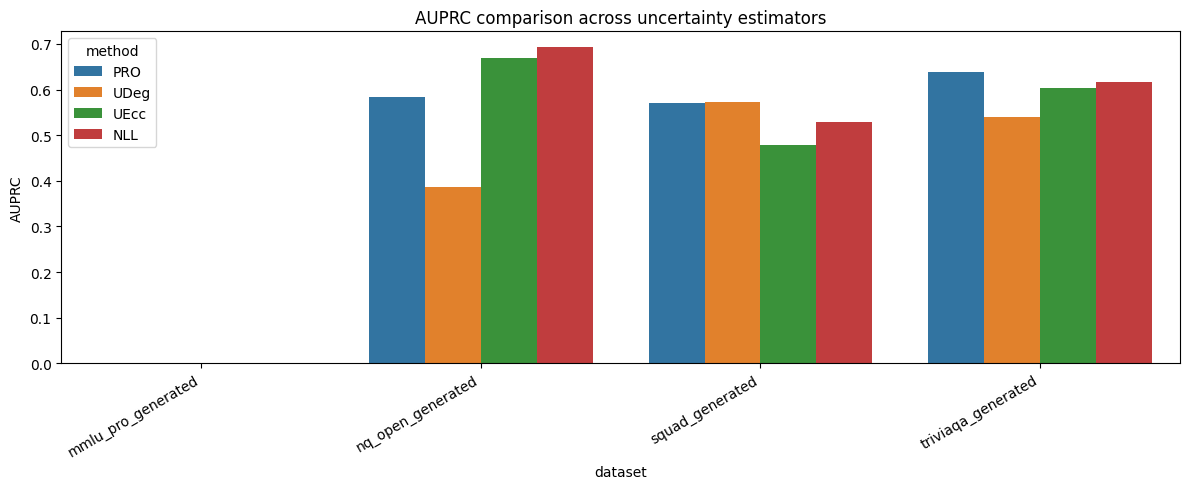

Saved plot: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/plots/auprc_comparison.png


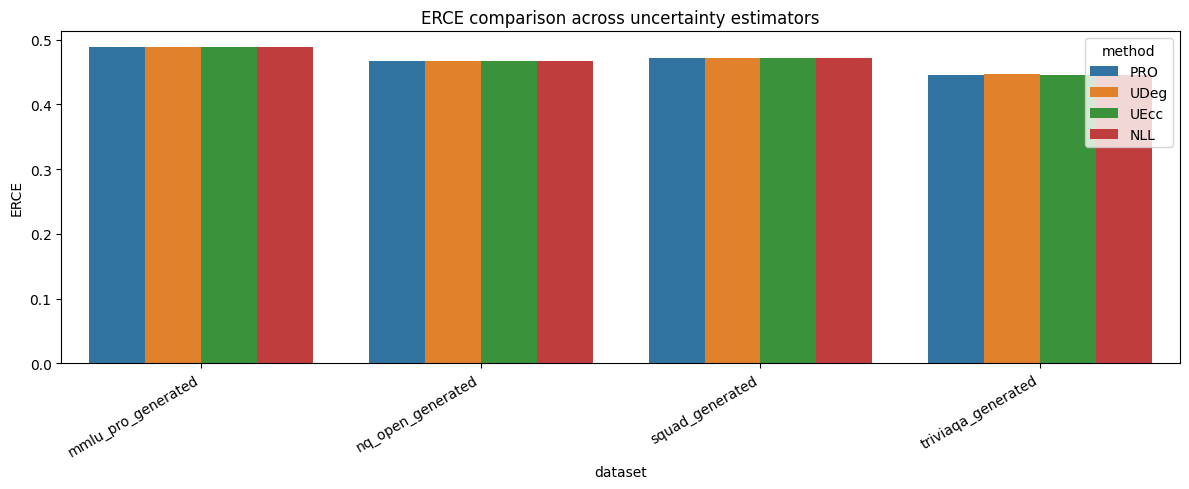

Saved plot: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/plots/erce_comparison.png


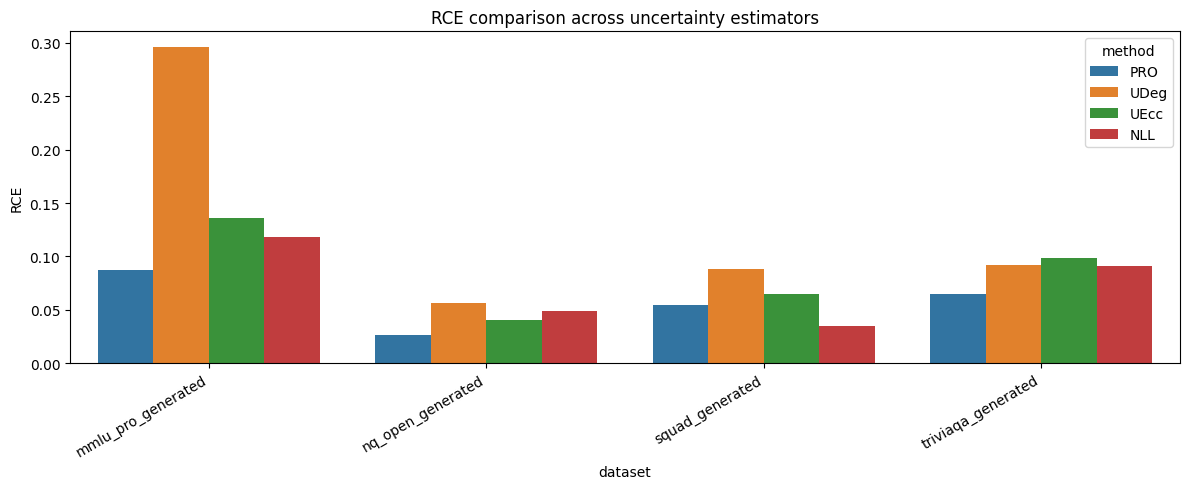

Saved plot: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/plots/rce_comparison.png


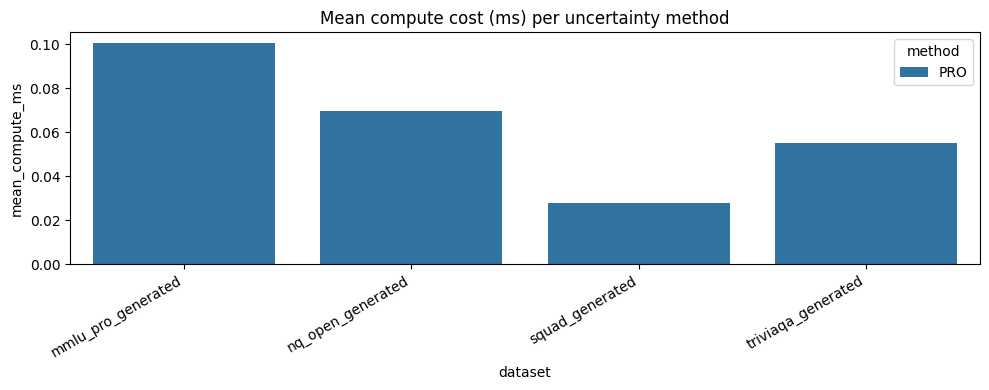

Saved plot: /media/abdullah/TUFF/pdc ann project/uncertainty-aware-distributed-inference/output/plots/compute_cost_comparison.png


In [14]:
# Plots: display and save
if 'compare_df' in globals() and len(compare_df) > 0:
    metric_list = ['AUROC', 'AUARC', 'AUPRC', 'ERCE', 'RCE']
    for metric in metric_list:
        plt.figure(figsize=(12, 5))
        sns.barplot(data=compare_df, x='dataset', y=metric, hue='method')
        plt.title(f'{metric} comparison across uncertainty estimators')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        out_file = PLOTS_DIR / f'{metric.lower()}_comparison.png'
        plt.savefig(out_file, dpi=200)
        plt.show()
        print('Saved plot:', out_file)

    plt.figure(figsize=(10, 4))
    tmp = compare_df.dropna(subset=['mean_compute_ms']).copy()
    if len(tmp) > 0:
        sns.barplot(data=tmp, x='dataset', y='mean_compute_ms', hue='method')
        plt.title('Mean compute cost (ms) per uncertainty method')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        out_file = PLOTS_DIR / 'compute_cost_comparison.png'
        plt.savefig(out_file, dpi=200)
        plt.show()
        print('Saved plot:', out_file)

## 7) Notes for report writing
- **Proposed Method:** PRO as a new uncertainty estimator under rank-calibration evaluation.
- **Additional Dataset:** MMLU-Pro subset from full download.
- **Core claim to test:** PRO achieves competitive ERCE/AUROC with lower compute cost.
- **Double value:** This validates your ANN extension and supports PRO-based routing in the PDC system.

If needed, add AUARC/AUPRC cells using the same `dataset_frames` objects.